In [14]:
import pandas as pd
import matplotlib.pyplot as plt

SELECT ROUND(SUM(price), 2) AS total_price, 
COUNT(DISTINCT oi.order_id) AS total_amount,
ROUND(SUM(price), 2) / COUNT(DISTINCT oi.order_id) AS avg_receipt
FROM order_items_dataset AS oi JOIN orders_dataset AS o ON oi.order_id = o.order_id
WHERE o.order_status = 'delivered';

Общее количество выручки: 13,221,498
Общее количество заказов: 96478
Средний чек: 137

SQL-запрос для proceeds_per_month.csv

SELECT DATE_FORMAT(order_purchase_timestamp, '%Y-%m') AS month_date,
SUM(price) AS total_month_proceeds
FROM order_items_dataset AS oi JOIN orders_dataset AS o ON oi.order_id = o.order_id
WHERE o.order_status = 'delivered'
GROUP BY month_date
ORDER BY month_date;

In [15]:
data1 = pd.read_csv('proceeds_per_month.csv')
data1

,month_date,total_month_proceeds
0,2016-09,134.97
1,2016-10,40325.11
2,2016-12,10.90
3,2017-01,111798.36
4,2017-02,234223.40
5,2017-03,359198.85
6,2017-04,340669.68
7,2017-05,489338.25
8,2017-06,421923.37
9,2017-07,481604.52


<function matplotlib.pyplot.show(close=None, block=None)>

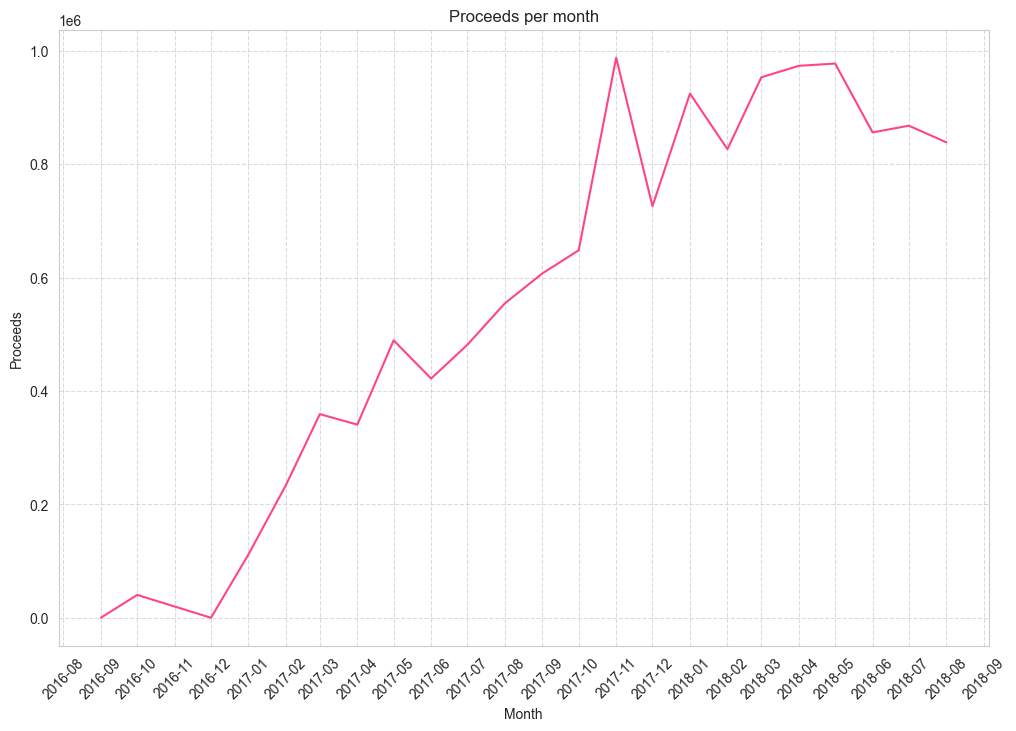

In [16]:
import matplotlib.dates as mdates
data1['month_date'] = pd.to_datetime(data1['month_date'], format='%Y-%m')

plt.figure(figsize=(12,8))
plt.plot(data1['month_date'], data1['total_month_proceeds'], color='#ff467e')
plt.title('Proceeds per month')
plt.xlabel('Month')
plt.ylabel('Proceeds')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show
         

Начиная с конца 2016 года выручка растет, особенно сильный рост наблюдается с декабря 2016 по март 2017. Это может говорить о расширении клиентской базы
Также можно заметить, что в марте и мае 2017 и 2018 наблюдаются пики, что может быть связано с сезонными распродажами и "Черными пятницами" в эти месяцы. Самый большой пик приходится на ноябрь 2017. Это может быть связано с большими распродажами и с тем, что люди стараются закупиться заранее перед Новым годом. К тому же, как известно, в декабре в Бразилии сезон отпусков, поэтому люди больше тратят деньги не на онлайн шоппинг, а на отдых

C:\Users\Асус\AppData\Local\Temp\ipykernel_25660\4211606146.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


<Axes: xlabel='proceeds', ylabel='category_en'>

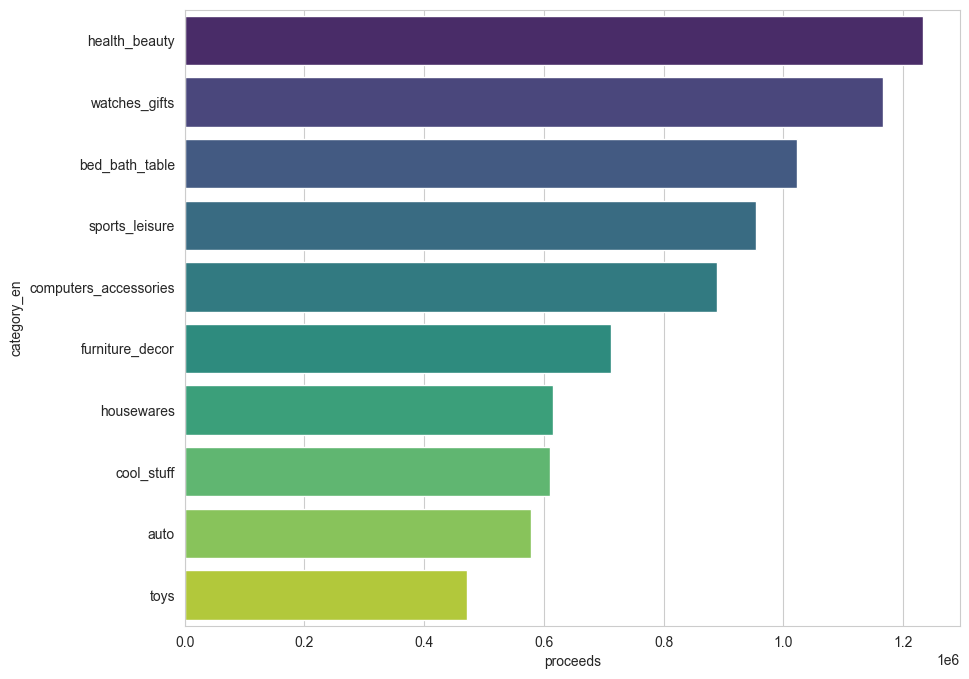

In [17]:
import seaborn as sns
data2 = pd.read_csv('proceeds_category.csv')

sns.set_style("whitegrid")
plt.figure(figsize=(10, 8))

sns.barplot(
    data=data2,
    y='category_en',
    x='proceeds',
    palette='viridis'
)

Лидер: категория "health_beauty". Приносит 1,233,131 (9,33% выручки)
Топ-3: health_beauty, watches_gifts(1,166,176, 8,82% выручки), bed_bath_table(1,023,434, 7,74% выручки)
3 категории с минимальной выручкой: cds_dvds_musicals(730, 0,01% выручки), fashion_childrens_clothes(519, <0,01% выручки), security_and_services(283, <0,01% выручки)

SQL-запрос для top_states.csv

SELECT 
    c.customer_state,
    SUM(oi.price) AS proceeds
FROM order_items_dataset oi
JOIN orders_dataset o ON oi.order_id = o.order_id
JOIN customers_dataset c ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
GROUP BY c.customer_state
ORDER BY proceeds DESC
LIMIT 10;

C:\Users\Асус\AppData\Local\Temp\ipykernel_25660\3452538824.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data3,


<Axes: xlabel='proceeds', ylabel='customer_state'>

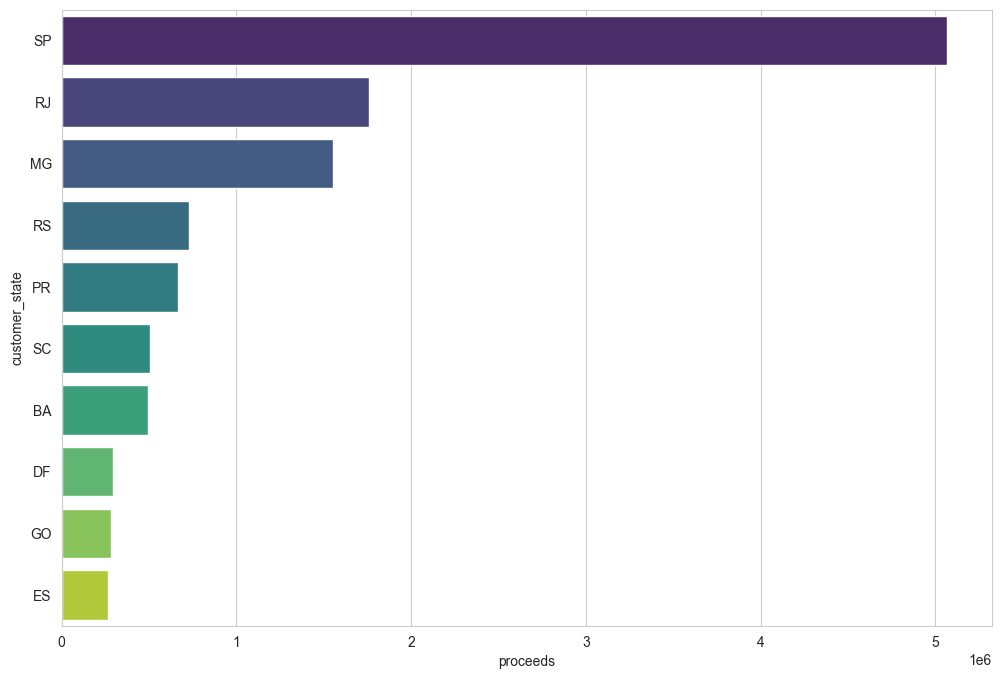

In [18]:
data3 = pd.read_csv('top_states.csv')

plt.figure(figsize=(12,8))

sns.barplot(data=data3,
            y='customer_state',
            x='proceeds',
            palette='viridis')

Лидер: штат SP (Сан-Паулу) - 5,067,633 (38,3% выручки)
Топ-3: SP, RJ (Рио-де-Жанейро, 1,759,651, 13,3%), MG (Минас-Жерайс, 1,552,481, 11,7%)

Когортный анализ

SQL-запрос для cohorta.csv

WITH FirstDate AS (
    SELECT 
        c.customer_unique_id,
        MIN(o.order_purchase_timestamp) AS first_date
    FROM orders_dataset o
    JOIN customers_dataset c ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
),
MonthsDiff AS (
    SELECT 
        o.order_purchase_timestamp,
        c.customer_unique_id,
        DATE_FORMAT(f.first_date, '%Y-%m') AS cohort_month,
        (YEAR(o.order_purchase_timestamp) - YEAR(f.first_date)) * 12 
        + (MONTH(o.order_purchase_timestamp) - MONTH(f.first_date)) AS month_offset
    FROM orders_dataset o
    JOIN customers_dataset c ON o.customer_id = c.customer_id
    JOIN FirstDate f ON c.customer_unique_id = f.customer_unique_id
    WHERE o.order_status = 'delivered')

SELECT 
    cohort_month,
    month_offset,
    COUNT(DISTINCT customer_unique_id) AS customers
FROM MonthsDiff
GROUP BY cohort_month, month_offset
ORDER BY cohort_month, month_offset;

In [20]:
data4 = pd.read_csv('cohorta.csv')
data_piv = data4.pivot_table(
    values='customers',
    index='cohort_month',
    columns='month_offset')
data_piv = data_piv.fillna(0)

cohort_size = data_piv.iloc[:, 0]
cohort_retention = data_piv.div(cohort_size, axis=0) * 100

cohort_retention = cohort_retention.round(2)
cohort_retention

month_offset,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,100.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2016-10,100.0,0.00,0.00,0.00,0.00,0.00,0.38,0.00,0.00,0.38,0.00,0.38,0.00,0.38,0.00,0.38,0.00,0.38,0.76,0.76
2016-12,100.0,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2017-01,100.0,0.28,0.28,0.14,0.42,0.14,0.42,0.14,0.14,0.00,0.42,0.14,0.70,0.42,0.14,0.14,0.28,0.42,0.14,0.00
2017-02,100.0,0.18,0.31,0.12,0.43,0.12,0.25,0.18,0.12,0.18,0.12,0.31,0.12,0.18,0.12,0.06,0.06,0.18,0.00,0.00
2017-03,100.0,0.44,0.36,0.40,0.36,0.16,0.16,0.32,0.32,0.08,0.36,0.12,0.20,0.12,0.16,0.24,0.08,0.12,0.00,0.00
2017-04,100.0,0.62,0.22,0.18,0.27,0.27,0.35,0.31,0.31,0.18,0.27,0.09,0.04,0.04,0.09,0.09,0.13,0.00,0.00,0.00
2017-05,100.0,0.46,0.46,0.29,0.29,0.32,0.41,0.14,0.26,0.26,0.26,0.35,0.23,0.03,0.17,0.20,0.00,0.00,0.00,0.00
2017-06,100.0,0.49,0.40,0.43,0.30,0.40,0.36,0.23,0.13,0.20,0.30,0.36,0.16,0.16,0.23,0.00,0.00,0.00,0.00,0.00


SELECT 
    COUNT(DISTINCT customer_unique_id) AS total_customers,
    COUNT(DISTINCT CASE WHEN order_count > 1 THEN customer_unique_id END) AS repeat_customers
FROM (
    SELECT 
        c.customer_unique_id,
        COUNT(DISTINCT o.order_id) AS order_count
    FROM orders_dataset o
    JOIN customers_dataset c ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
) AS customer_orders;

Из данного запроса можно извлечь общее количество покупателей и количество покупателей, которые совершили хотя бы 2 заказа
Общее число: 93,358
Покупатели с хотя бы 2 заказами: 2,801
Общий уровень ретеншена: 3%, то есть 97% клиентов совершают только одну покупку. Это означает, что большинство клиентов приходят на маркетплейс и не возвращаются
На первый месяц составляет всего ~0.47%
Рекомендация: Внедрить программу лояльности и персонализированные email-рассылки для стимулирования повторных покупок в течение 30 дней после первого заказа

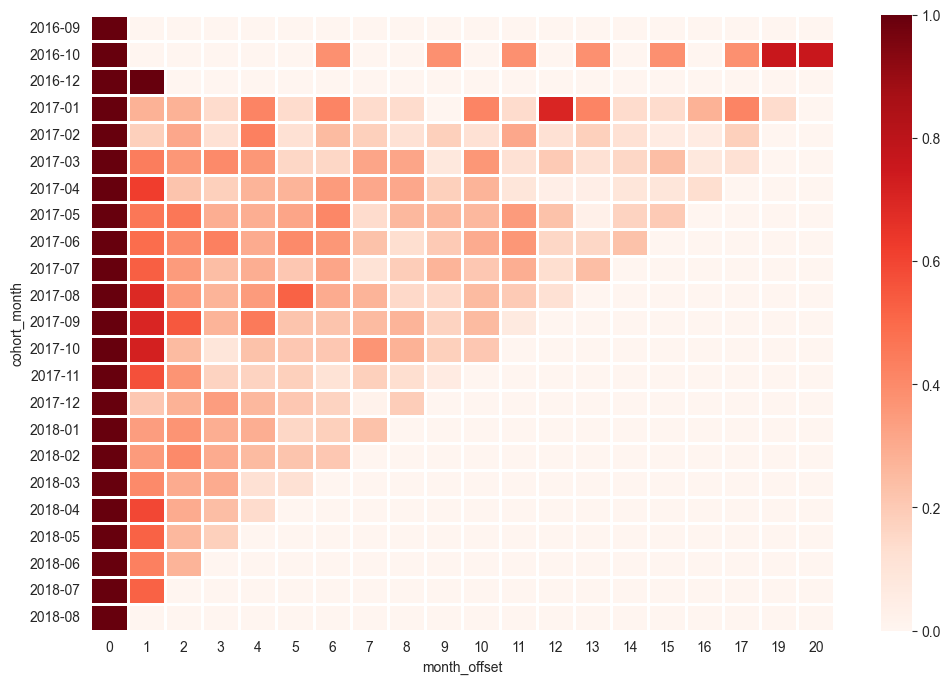

In [21]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    cohort_retention,
    fmt='.1f',              
    cmap='Reds',
    vmin=0,
    vmax=1,
    linewidths=0.9,
    linecolor='white')

plt.show()

SQL запрос для 'rfm.csv'

SELECT 
    c.customer_unique_id,
    DATEDIFF('2018-12-31', MAX(o.order_purchase_timestamp)) AS recency,
    COUNT(DISTINCT o.order_id) AS frequency,
    SUM(oi.price) AS monetary
FROM customers_dataset c
JOIN orders_dataset o ON c.customer_id = o.customer_id
JOIN order_items_dataset oi ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
GROUP BY c.customer_unique_id;


recency - как давно клиент купил товар (число дней от последней даты)
frequency - число покупок
monetary - общая выручка с клиента

In [23]:
rfm = pd.read_csv('rfm.csv')

rfm.head()

,customer_unique_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,235,1,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,238,1,18.90
2,0000f46a3911fa3c0805444483337064,661,1,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,445,1,25.99
4,0004aac84e0df4da2b147fca70cf8255,412,1,180.00


In [24]:
rfm['recency'].describe(percentiles=[0.2, 0.4, 0.6, 0.8, 0.9])

count    93358.000000
mean       361.478877
std        152.595054
min        124.000000
20%        216.000000
40%        301.000000
60%        392.000000
80%        506.000000
90%        589.000000
max        837.000000
Name: recency, dtype: float64

In [25]:
rfm['frequency'].unique()

array([ 1,  2,  3,  4,  6,  7,  5,  9, 15])

In [26]:
rfm['monetary'].describe(percentiles=[0.2, 0.4, 0.6, 0.8, 0.9])

count    93358.000000
mean       141.621480
std        215.694014
min          0.850000
20%         39.900000
40%         69.900000
60%        109.900000
80%        179.900000
90%        279.990000
max      13440.000000
Name: monetary, dtype: float64

Присваиваем бал в зависимости от показателя в recency, frequency, monetary: чем меньше recency, тем больше бал;
чем больше frequency, monetary, тем больше бал

In [28]:
rfm['R_score'] = pd.cut(
    rfm['recency'],
    bins=[0, 200, 300, 400, 500, 1000000],
    labels=[5, 4, 3, 2, 1]
)
rfm['F_score'] = pd.cut(
    rfm['frequency'],
    bins=[0, 1, 2, 4, 7, 1000000],
    labels=[1, 2, 3, 4, 5]
)
rfm['M_score'] = pd.cut(
    rfm['monetary'],
    bins=[0, 40, 70, 110, 180, 1000000],
    labels=[1, 2, 3, 4, 5]
)

rfm['RFM'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)
rfm.head()

,customer_unique_id,recency,frequency,monetary,R_score,F_score,M_score,RFM
0,0000366f3b9a7992bf8c76cfdf3221e2,235,1,129.90,4,1,4,414
1,0000b849f77a49e4a4ce2b2a4ca5be3f,238,1,18.90,4,1,1,411
2,0000f46a3911fa3c0805444483337064,661,1,69.00,1,1,2,112
3,0000f6ccb0745a6a4b88665a16c9f078,445,1,25.99,2,1,1,211
4,0004aac84e0df4da2b147fca70cf8255,412,1,180.00,2,1,4,214


In [29]:
def segment_customer(rfm):
    if rfm == '555':
        return 'Чемпион'
    elif rfm[0] == '5' and (rfm[1] == '5' or rfm[2] == '5'):
        return 'Лояльный'
    elif rfm[0] == '1' and (rfm[1] == '1' or rfm[2] == '1'):
        return 'Ушедший'
    elif rfm[0] == '5' and rfm[1] == '1' and rfm[2] == '1':
        return 'Новый'
    elif rfm[0] == '5' and rfm[1] == '1':
        return 'Нерегулярный'
    else:
        return 'Обычный'

rfm['segment'] = rfm['RFM'].apply(segment_customer)

rfm['segment'].value_counts()

segment
Обычный         58926
Ушедший         18963
Нерегулярный     9081
Новый            3400
Лояльный         2987
Чемпион             1
Name: count, dtype: int64

C:\Users\Асус\AppData\Local\Temp\ipykernel_25660\1436379020.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm, x='segment', palette='viridis')


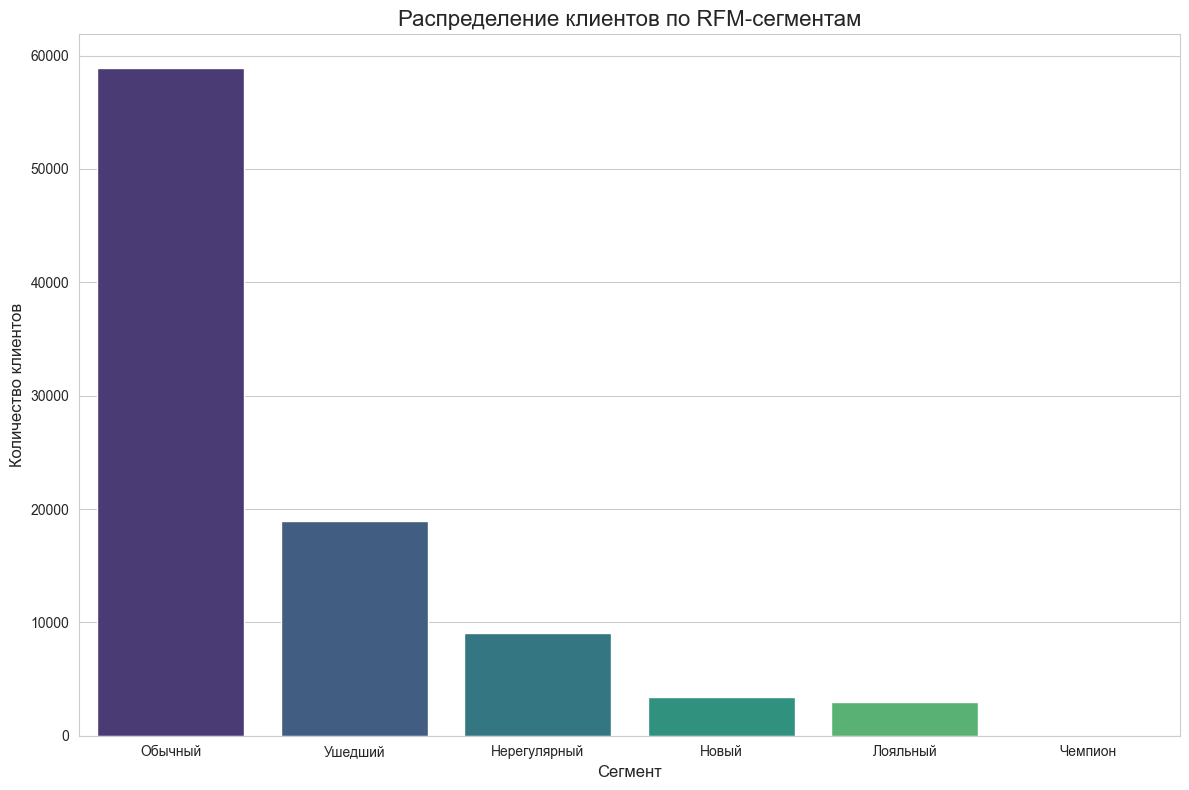

In [30]:
plt.figure(figsize=(12, 8))
sns.countplot(data=rfm, x='segment', palette='viridis')

plt.title('Распределение клиентов по RFM-сегментам', fontsize=16)
plt.xlabel('Сегмент', fontsize=12)
plt.ylabel('Количество клиентов', fontsize=12)
plt.tight_layout()
plt.show()

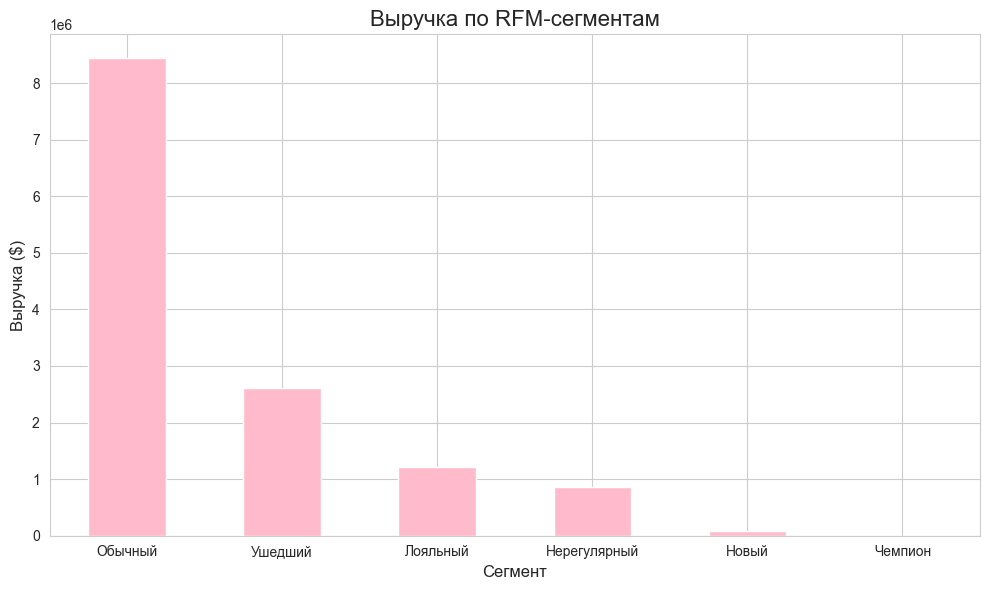

In [31]:
segment_revenue = rfm.groupby('segment')['monetary'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
segment_revenue.plot(kind='bar', color='#ffbbcc')
plt.title('Выручка по RFM-сегментам', fontsize=16)
plt.xlabel('Сегмент', fontsize=12)
plt.ylabel('Выручка ($)', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

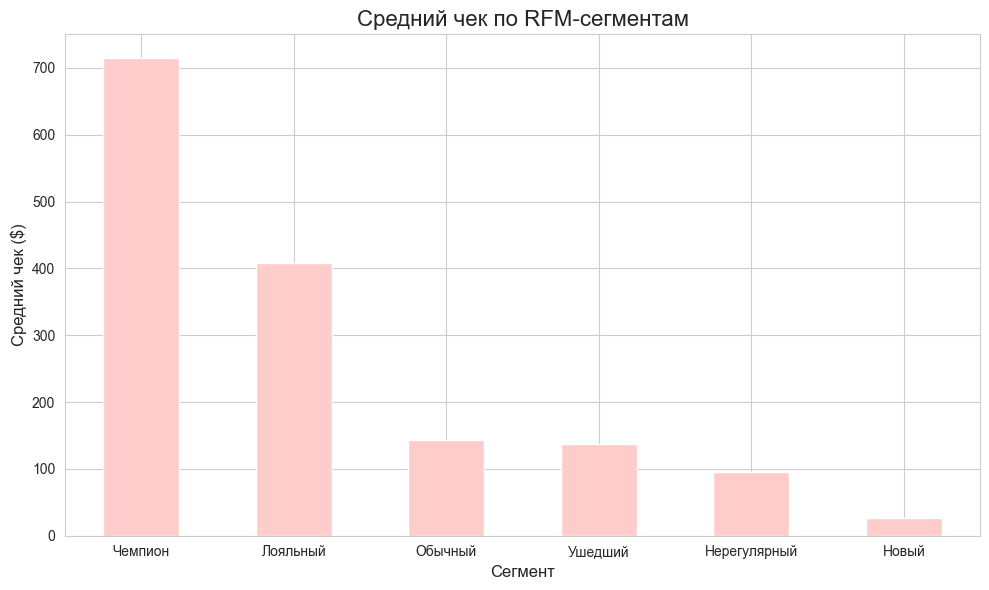

In [32]:
segment_avg = rfm.groupby('segment')['monetary'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
segment_avg.plot(kind='bar', color='#ffcccc')
plt.title('Средний чек по RFM-сегментам', fontsize=16)
plt.xlabel('Сегмент', fontsize=12)
plt.ylabel('Средний чек ($)', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [33]:
segment_avg = rfm.groupby('segment')['monetary'].mean().sort_values(ascending=False)
segment_avg

segment
Чемпион         714.630000
Лояльный        407.890730
Обычный         143.200835
Ушедший         137.395783
Нерегулярный     95.609036
Новый            26.617521
Name: monetary, dtype: float64

Наибольшую общую выручку приносят "обычные" клиенты, при этом максимальный средний чек приносит единственный "чемпион", у "обычных" же средний чек на 4% меньше, чем у лидера